# H1 — 자동 혼동 그룹 Mixture-of-Experts

기준은 최종 H0 Selective-EB seed42 OOF 0.547915입니다. 자동 그룹은 각 outer-fold train의 inner OOF에서만 발견하며, expert는 그룹 내부 확률 비율만 바꾸고 H0의 그룹 확률 질량은 보존합니다.

In [1]:
from pathlib import Path
import subprocess, sys, json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
RUNNER = ROOT / 'experiments/gs/notebooks/exp_model_010/common/run_h1_auto_confusion_moe_selective_eb.py'
RESULT = ROOT / 'experiments/gs/notebooks/exp_model_010/result'
RUN_ID = 'exp-h1-auto-confusion-moe-selective-eb-01'
RUN_EXPERIMENT = True  # smoke 확인 뒤 True로 변경
assert RUNNER.exists()
print({'runner': RUNNER, 'reference_h0_seed42': 0.547915, 'outer': '5-fold seed42', 'inner': '3-fold fold-train only'})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/common/run_h1_auto_confusion_moe_selective_eb.py'), 'reference_h0_seed42': 0.547915, 'outer': '5-fold seed42', 'inner': '3-fold fold-train only'}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# train schema, NaN 처리, 자동 그룹 로직의 빠른 smoke 검사
subprocess.run([sys.executable, str(RUNNER), '--smoke'], check=True)

{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "fixed_rules": false}


CompletedProcess(args=['/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/bin/python', '/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_010/common/run_h1_auto_confusion_moe_selective_eb.py', '--smoke'], returncode=0)

In [3]:
if RUN_EXPERIMENT:
    process = subprocess.Popen([sys.executable, str(RUNNER), '--run-id', RUN_ID], stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H1 auto-confusion MoE', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('H1 runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과가 있다면 집계만 수행합니다.')

H1 auto-confusion MoE: 1line [00:04,  4.91s/line]

[H1] fold 1/5: inner OOF for automatic groups


H1 auto-confusion MoE: 2line [09:59, 352.02s/line]

[H1] fold 1/5 groups=(('ACC',), ('BLCA', 'BRCA', 'CESC', 'GBMLGG', 'HNSC', 'KIPAN', 'KIRC', 'LAML', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'OV', 'PAAD', 'PCPG', 'PRAD', 'SARC', 'STES', 'THCA', 'THYM', 'UCEC'), ('COAD',), ('DLBC',), ('SKCM',), ('TGCT',))


H1 auto-confusion MoE: 3line [15:07, 331.74s/line]

...

H1 auto-confusion MoE: 10line [1:08:32, 448.20s/line]

[H1] fold 5/5 groups=(('ACC',), ('BLCA',), ('BRCA', 'CESC', 'COAD', 'GBMLGG', 'HNSC', 'KIPAN', 'KIRC', 'LAML', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'OV', 'PAAD', 'PCPG', 'PRAD', 'SARC', 'STES', 'THCA', 'THYM', 'UCEC'), ('DLBC',), ('SKCM',), ('TGCT',))


H1 auto-confusion MoE: 11line [1:13:18, 398.75s/line]

{"run_id": "exp-h1-auto-confusion-moe-selective-eb-01", "h0_reference": 0.547915, "h0_reference_match": true, "h0_reference_delta": -3.387370274277046e-07, "outer_splits": 5, "inner_splits": 3, "automatic_group_count": 6, "positive_fold_count": 0, "low_margin_h0": 0.23409076498652398, "low_margin_h1": 0.1997884921962216, "low_margin_delta": -0.034302272790302374, "test_read": false, "train_test_concat": false, "fixed_class_gene_mutation_rules": false, "leakage_check": true, "nan_as_mutation_count": 0, "decision": "rejected"}


H1 auto-confusion MoE: 11line [1:13:19, 399.93s/line]


In [4]:
summary = pd.read_csv(RESULT / f'{RUN_ID}_seed42_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_seed42_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_seed42_class_metrics.csv')
groups = pd.read_csv(RESULT / f'{RUN_ID}_seed42_auto_groups.csv')
audit = json.loads((RESULT / f'{RUN_ID}_seed42_leakage_audit.json').read_text())
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False and audit['leakage_check'] is True
display(summary)
display(folds.pivot(index='fold', columns='variant', values='macro_f1'))
display(groups.sort_values(['fold', 'group_id']))
audit

,variant,oof_macro_f1,oof_accuracy,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,H0_selective_EB,0.547915,0.558942,8219.2,0,True,0,4396.835035,0.000000
1,H1_auto_confusion_moe,0.512330,0.513788,8219.2,0,True,0,4396.835064,-0.035584


variant,H0_selective_EB,H1_auto_confusion_moe
fold,,
1,0.528516,0.484266
2,0.551891,0.505063
3,0.543449,0.534054
4,0.554759,0.515500
5,0.558499,0.522967


,fold,group_id,classes,size,fit_support,used
0,1,1,BLCA|BRCA|CESC|GBMLGG|HNSC|KIPAN|KIRC|LAML|LGG...,21,4374,True
1,2,2,BRCA|CESC|COAD|GBMLGG|HNSC|KIPAN|KIRC|LAML|LGG...,21,4469,True
2,3,2,BRCA|CESC|COAD|GBMLGG|HNSC|KIPAN|KIRC|LAML|LGG...,21,4470,True
3,4,2,BRCA|CESC|COAD|GBMLGG|HNSC|KIPAN|KIRC|LAML|LGG...,21,4471,True
4,5,2,BRCA|CESC|COAD|GBMLGG|HNSC|KIPAN|KIRC|LAML|LGG...,21,4469,True


{'run_id': 'exp-h1-auto-confusion-moe-selective-eb-01',
 'h0_reference': 0.547915,
 'h0_reference_match': True,
 'h0_reference_delta': -3.387370274277046e-07,
 'outer_splits': 5,
 'inner_splits': 3,
 'automatic_group_count': 6,
 'positive_fold_count': 0,
 'low_margin_h0': 0.23409076498652398,
 'low_margin_h1': 0.1997884921962216,
 'low_margin_delta': -0.034302272790302374,
 'test_read': False,
 'train_test_concat': False,
 'fixed_class_gene_mutation_rules': False,
 'leakage_check': True,
 'nan_as_mutation_count': 0,
 'decision': 'rejected'}

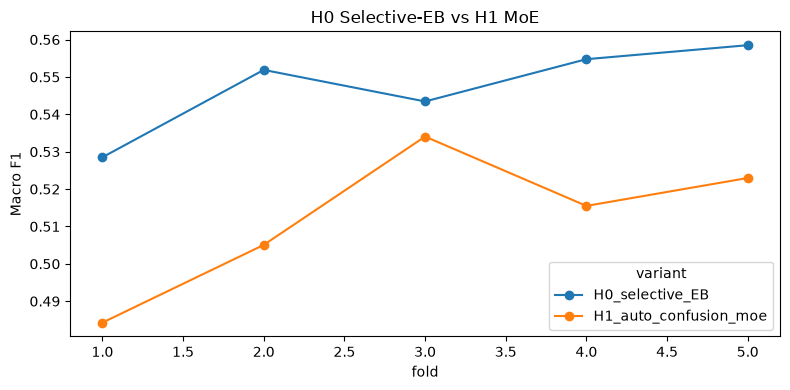

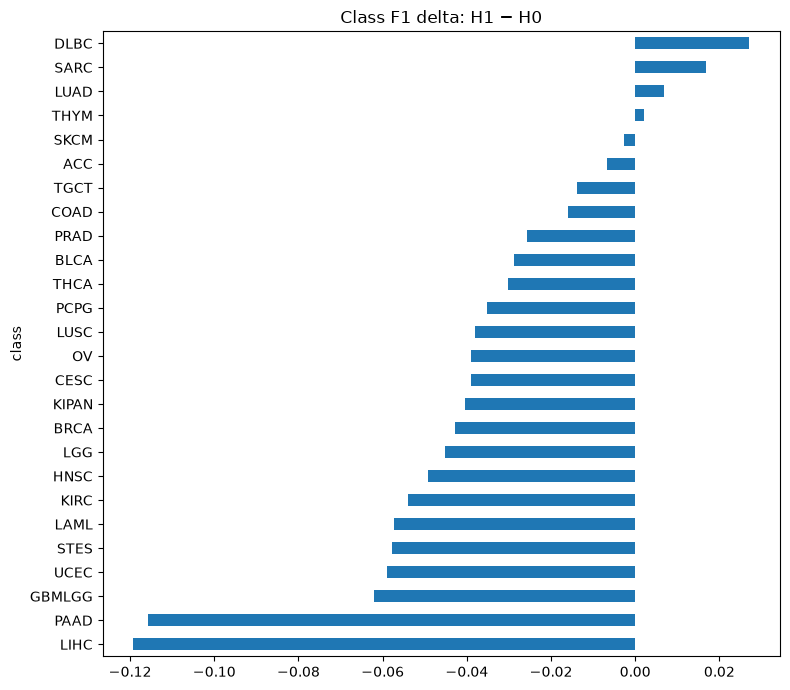

positive folds: 0 / 5
decision: rejected


In [5]:
pivot = folds.pivot(index='fold', columns='variant', values='macro_f1')
pivot.plot(marker='o', figsize=(8,4), title='H0 Selective-EB vs H1 MoE')
plt.ylabel('Macro F1'); plt.tight_layout(); plt.show()
classes.sort_values('f1_delta').set_index('class').f1_delta.plot.barh(figsize=(8,7), title='Class F1 delta: H1 − H0')
plt.tight_layout(); plt.show()
print('positive folds:', int((pivot['H1_auto_confusion_moe'] > pivot['H0_selective_EB']).sum()), '/ 5')
print('decision:', audit['decision'])